# Classification

Classification problem is another supervised learning problem. The difference between regression and classification is the labels $y$. If $y$ can take any values, then it is a regression problem. If $y$ only takes discrete values, then it is a classification problem.


# Classification example

We can use the `make_classification` command to generate synthetic data samples.

    sklearn.datasets.make_classification(n_samples=100, n_features=20, *, n_informative=2, n_redundant=2, n_repeated=0, n_classes=2, n_clusters_per_class=2, weights=None, flip_y=0.01, class_sep=1.0, hypercube=True, shift=0.0, scale=1.0, shuffle=True, random_state=None)

In [66]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

X, Y = make_classification(n_samples=10000, n_features = 30, n_informative=6, n_classes=3)
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2)

## K-nearest neighbors (KNN)

#### Algorithm explanation:

An object is classified by a plurality vote of its neighbors, with the object being assigned to the class most common among its k nearest neighbors (k is a positive integer, typically small). If k = 1, then the object is simply assigned to the class of that single nearest neighbor.

#### Figure explanation:
![](https://miro.medium.com/v2/resize:fit:640/format:webp/0*KxkMe86skK9QRcJu.jpg)
This figure is from a Medium post, see [link](https://medium.com/swlh/k-nearest-neighbor-ca2593d7a3c4), by courtesy of Antony Christopher.

#### Training

We do not need to train KNN model, or do not need to solve an optimization problem. We only compute the pariwise distance. 

#### Distances
Given two points $(x_1,\dots,x_d)$ and $(y_1,\dots,y_d)$, we can compute
- Euclidean distance: Euclidean distance is calculated as the square root of the sum of the squared differences between two points. $d(x,y) = \sqrt{ \sum_{i=1}^d (x_i-y_i)^2 } $
- Manhattan Distance: This is the distance between real vectors using the sum of their absolute difference. $d_M(x,y) = \sum_{i=1}^d |x_i-y_i|$

#### Regression
K-nearest neighbors algorithm can also be used for regression problem. In k-NN regression, the output is the property value for the object. This value is the average of the values of k nearest neighbors. If k = 1, then the output is simply assigned to the value of that single nearest neighbor.

#### Hyper-parameter

Hyperparameters are external configuration settings used to structure machine learning models and control the learning process, which are set by the user before training begins.

The number of nearest neighbors (k) is a hyper-parameter. You can use cross-validation to select the best number of neighbors.

#### Documentation:
Python documentation: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

In [67]:
from sklearn.neighbors import KNeighborsClassifier

# train the model


# test accuracy


# compute test accuracy without using score


# return probability


Test accuracy is 0.75
Test accuracy is 0.75
[[0.4 0.4 0.2]
 [1.  0.  0. ]
 [0.2 0.7 0.1]
 ...
 [0.  0.8 0.2]
 [0.  0.8 0.2]
 [0.  0.1 0.9]]


## Logistic Regression


### Intuition

Logistic regression = logistic function (sigmoind function) + linear regression. **Logistic regression is designed for classification problems only. In other words, you can not use this model for regression problems.**

Linear regression cannot be directly used for classification problems because target is continuous variable (or can take any real values), while classification problem has discrete values. After applying the logistic function (see below), the returned values lie in interval [0,1], which represents the probability.


### Formula:

The binary logistic regression formula is

$$ P(Y=1) = \frac{1}{1+\exp( - (w_0+w_1x_1+\dots+w_dx_d) )} $$

$$ P(Y=0) = 1 - P(Y=1) $$

Moreover, we can show that 

$$ \log\left(\frac{p}{1-p}\right) = -(w_0+w_1x_1+\dots+w_dx_d), $$
where $p=P(Y=1)$.


In other words, **Logistic regression model assumes that the logit can be well-approximated by a linear regression model.**


**For the binary classification problem, we assume that target $Y$ takes value either 0 and 1.** If the dataset has binary labels (-1 and 1), then we need to transform them to (0 and 1). However, we never do this on our own since Python library sklearn does this automatically.


### Multi-class classification

We can do either 
- Multinomial/Softmax Regression: Learns one set of weights per class directly.
- One-vs-Rest (OvR): Trains $k$ separate binary classifiers (class A vs. not-A).

Sklearn do it for you, so we do not worry about it. 

#### Formula for Multinomial/Softmax

We assume that the probability of belonging to class i is model as

$$ P(Y=i | X) = \frac{\exp(-w_i^\top f(X))}{\sum_{i} \exp(-w_i^\top f(X))} $$


### Documentation

Python documentation: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

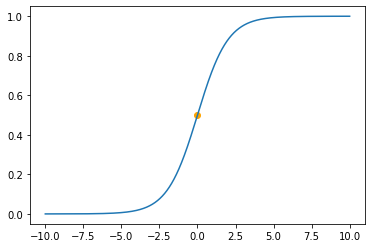

In [68]:
def logistic(x):
    
    return 1/(1+np.exp(-x))

x = np.linspace(-10,10,3000)
y = logistic(x)
plt.plot(x,y)

plt.scatter([0],[1/2],c='orange')

In [69]:
# train the model
from sklearn.linear_model import LogisticRegression



# test accuracy


# compute test accuracy without using score


# return probability


Test accuracy is 0.64
Test accuracy is 0.64
[[0.12632938 0.32725923 0.54641139]
 [0.68363996 0.08218355 0.23417649]
 [0.21792276 0.62964389 0.15243335]
 ...
 [0.07807654 0.81554025 0.10638321]
 [0.15311595 0.70410416 0.14277989]
 [0.02659875 0.53800197 0.43539927]]


# Support Vector Machine


## Intuition

Support Vector Machine (SVM) finds the optimal separating hyperplane that maximizes the margin.

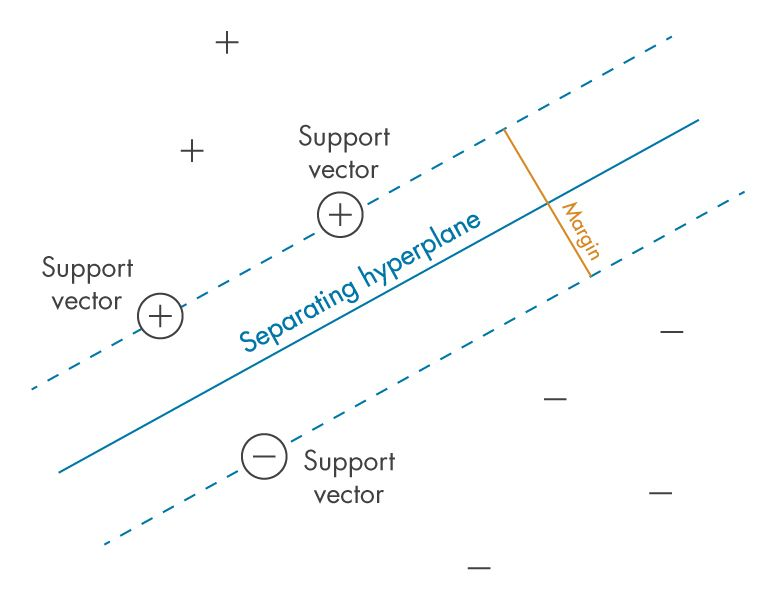


Why maximized margin? **Robust classifier and better generalization (no bias to a certain category).**

## Formula:

Hyperplane: $w_0+w_1x_1+\dots+w_dx_d=0$

Positive category (y=+1): $w_0+w_1x_1+\dots+w_dx_d>0$

Negative category (y=-1): $w_0+w_1x_1+\dots+w_dx_d<0$

An object is classified by $(w_0+w_1x_1+\dots+w_dx_d)y>0$, which is called hard constraint.

**The math formula indicates that targets are labeled as +1 and -1.**


## Non-separabale Data:

We allow misclassified samples, see this note [here](https://htmlpreview.github.io/?https://github.com/foucart/Mathematical_Pictures_at_a_Data_Science_Exhibition/blob/master/Python/web/Chapter04.html). 

In python, it is controlled by a hyper-parameter C. Large C means that the model does not allow too many misclassified samples, while small C means that it allows many miscalssified samples.

- If you know your data is well-separated, you should use Large C.
- In practice, it is hard to know whether the data is well-separated or not. Therefore, we use cross-validation to select the optimal C.



In [70]:
from sklearn.svm import SVC



##################### SVM

# SVM is not a probabilistic model, so classic SVM does not compute probability.
# After extra post processing, Sklearn returns probability and it is interpreted as prediction confidence


Test accuracy is 0.80


In [72]:
# An example of Cross-validation
from sklearn.model_selection import GridSearchCV
# Model


# Parameter grid


# Grid search with cross-validation


# Fit


# Results


# get the best hyper-parameter


############## Retrain the model


# compute test accuracy without using score


Best C: 1
Best CV score: 0.795625
Test accuracy is 0.80


In [73]:
# Manually
from sklearn.model_selection import cross_val_score



Best C: 1
Scores: [0.660875, 0.734, 0.795625, 0.7843749999999999, 0.7732499999999999]


# Kernel Method

Kernel method (kernel trick) enables nonlinear decision boundary / relationship for linear models. For example, 
- kernel method + linear regression => kernel regression, 
- kernel method + rdige regression => kernel ridge regression, and
- kernel method + SVM => kernel SVM.


![](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*zWzeMGyCc7KvGD9X8lwlnQ.png)

## Strengths

Kernel function measures the similarity of new features in the feature space, while the computation only uses the samples in the original input space. Therefore, kernel method enjoys the fast computation in the low-dimensional space and the powerful representation in the high-dimensional space.

In [11]:
# RBF Kernel

Test accuracy is 0.33


In [12]:
# Polynomial Kernel

Test accuracy is 0.79


# Tree based model

A decision tree looks like this: ![](https://scikit-learn.org/stable/_images/sphx_glr_plot_iris_dtc_002.png)


A decision tree is a flowchart-like structure in which each internal node represents a "test" on an attribute (e.g. whether a coin flip comes up heads or tails), each branch represents the outcome of the test, and each leaf node represents a class label (decision taken after computing all attributes). The paths from root to leaf represent classification rules.

#### Prediction

For the classification problem, a new object is classified by a plurality vote at a leaf node. For the regression problem, a new object is predicted by computing the average at a leaf node. 


#### Limitations

Usually, we do not use single tree models because

- High-variance (unstable). A small change in the training data can produce a very different tree structure.
- Overfitting. A fully grown tree can perfectly fit training data, memorize noise, and create extremely deep, fragmented regions. Even with pruning, trees tend to over-partition space.
- The decision boundary is highly non-smooth. It works poorly in linear structures.  


Python documentation: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

In [13]:
from sklearn.tree import DecisionTreeClassifier, plot_tree




Test accuracy is 0.67
Test accuracy is 0.67
[[0.74145299 0.06837607 0.19017094]
 [0.19967356 0.19368879 0.60663765]
 [0.10559796 0.81743003 0.07697201]
 ...
 [0.74145299 0.06837607 0.19017094]
 [0.19967356 0.19368879 0.60663765]
 [0.0325477  0.46857464 0.49887767]]


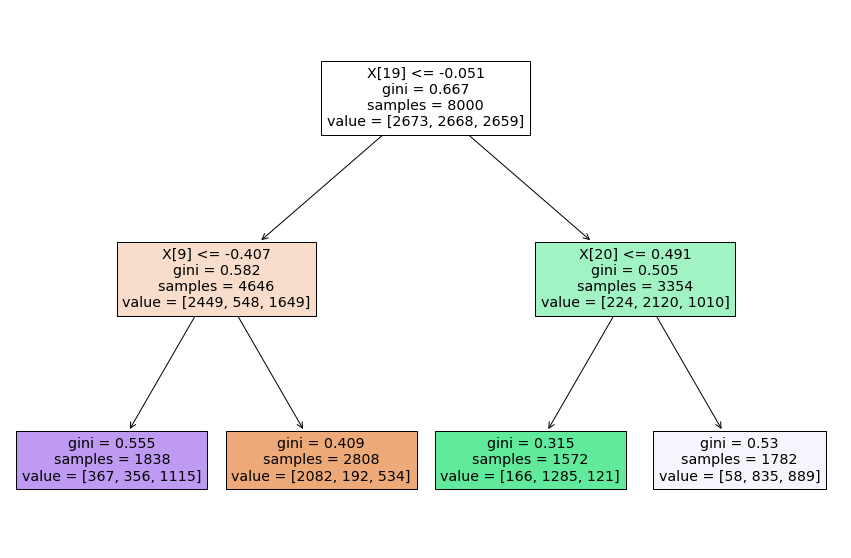

## Ensemble Learning

To better understand random forest model, we should know **Ensemble Learning** first, which is an important technique in Machine Learning.

#### Motivation:

Suppose that you have a complex question of thousands of random people, then aggregate their answers. In many cases you will find yjay yhis aggregated answer is better than an expert's answer. This is called the *wisdom of the crowd*. Similarly, if you aggregate the predictions of a groups of predictors (such as classifiers or regressors), you will often get better predictions than with the best individual predictor. A group of predictors is called an ensemble; thus this technique is called Ensemble Learning.

#### When do we use ensemble model?

Usually, ensemble model works better than single model, but there is no guarantee. In my opinion, since we must try different single models due to No Free Luch Theorem, it does not hurt to ensemble all single models you have tried, and look at the performance on test dataset.

#### Example:

Let's ensemble KNNeighbor, Logistic Regression, and Tree model together.

Python documentation: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.VotingClassifier.html

In [15]:
from sklearn.ensemble import VotingClassifier

# define classifiers you want to use

# define max vote classifier


# train max vote classifier


# let's look at each classifier's accuracy on the test set:


KNeighborsClassifier 0.8545
LogisticRegression 0.7555
DecisionTreeClassifier 0.84
VotingClassifier 0.866


## Random Forest

In short, random forest is an ensemble of decision trees. 

A group of Decision Tree classifiers are trained on a different random subset of the training set. Then, you use max vote (ensemble technique) to obtain the prediction. 


Python documentation: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html


In [16]:
from sklearn.ensemble import RandomForestClassifier

# train random feature model


Test accuracy is 0.901
[[0.07 0.17 0.76]
 [0.09 0.08 0.83]
 [0.05 0.94 0.01]
 ...
 [0.22 0.4  0.38]
 [0.66 0.02 0.32]
 [0.01 0.48 0.51]]


# Numerical Verification


In this section, we will run some experiments to verify our theory. The goal is to help understand each model. Some specific problems are 

- why does each model work/fail?
- When do we you KNN, Logistic Regression, SVM, Kernel Method, and Tree-based model?

In practice, we may not be able to visualize data, or data is not as nice as I have. So, we should try all methods.


## Example 1: Nonlinear Decision Boundary

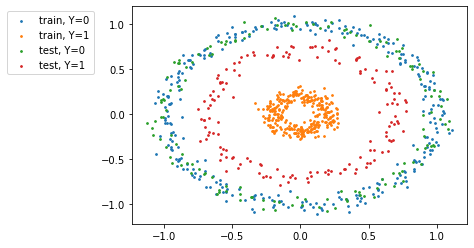

In [32]:
from sklearn.datasets import make_circles

# TRAIN: tight circles
X_train, y_train = make_circles(n_samples=600, factor=0.2, noise=0.05, random_state=0)

# TEST: looser circles (different geometry)
X_test, y_test = make_circles(n_samples=300, factor=0.7, noise=0.05, random_state=1)


# Data Visualization
plt.scatter( X_train[y_train==0,0], X_train[y_train==0,1], label='train, Y=0', s=3)
plt.scatter( X_train[y_train==1,0], X_train[y_train==1,1], label='train, Y=1', s=3)
plt.scatter( X_test[y_test==0,0], X_test[y_test==0,1], label='test, Y=0', s=3)
plt.scatter( X_test[y_test==1,0], X_test[y_test==1,1], label='test, Y=1', s=3)
plt.legend(loc='best',bbox_to_anchor=[-0.1,1])

Test Accuracy:
KNN:                 0.5166666666666667
Logistic Regression: 0.49
SVM:                 0.5066666666666667
SVM with RBF kernel: 0.8733333333333333
Random Forest:       0.5


## Example 2: KNN fails in the high-dimensional case

In [74]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

def make_high_dim_data(n_train=1000, n_test=300, d=2):
    # only first dimension matters
    X_train = np.random.randn(n_train, d)
    X_test = np.random.randn(n_test, d)

    y_train = (X_train[:, 0] > 0).astype(int)
    y_test = (X_test[:, 0] > 0).astype(int)

    return X_train, X_test, y_train, y_test


d

Dim=  2 | KNN accuracy = 0.987
Dim=  5 | KNN accuracy = 0.913
Dim= 10 | KNN accuracy = 0.837
Dim= 50 | KNN accuracy = 0.673
Dim=100 | KNN accuracy = 0.650


Dim=  2 | KNN accuracy = 0.990
Dim=  5 | KNN accuracy = 0.970
Dim= 10 | KNN accuracy = 0.933
Dim= 50 | KNN accuracy = 0.923
Dim=100 | KNN accuracy = 0.873


# Example 3: The choice of C in SVM

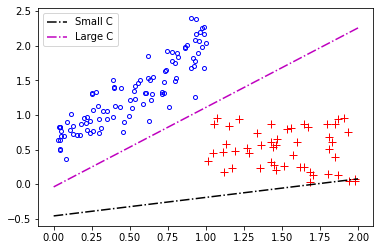

In [81]:
# SVM: C
import numpy as np
import matplotlib.pyplot as plt

# Generate each category
m0 = 100
m1 = 50
X0_x = np.random.uniform(0,1,m0)                               # abscissae of the blue dots
X0_y = 3/2*X0_x + 1/2 + np.random.normal(0,0.2,m0)             # their ordinates
X0 = np.column_stack((X0_x,X0_y))
X1_x = np.random.uniform(1,2,m1)                               # abscissae of the red crosses
X1_y = np.random.uniform(0,1,m1)                               # their ordinates
X1 = np.column_stack((X1_x,X1_y))

X = np.row_stack((X0,X1))
# Labels should be either +1 or -1
Y = np.ones((m0+m1,))
Y[m0:] = -1


from sklearn.svm import LinearSVC
# use linear SVC because I can get the optimal hyperplane
model1 = LinearSVC(C=0.0001)
model1.fit(X,Y)
w1 = model1.coef_[0]
b1 = model1.intercept_


model2 = LinearSVC(C=1000)
model2.fit(X,Y)
w2 = model2.coef_[0]
b2 = model2.intercept_

# Visualization:
grid_x = np.linspace(0,2,20)
plt.plot(X0[:,0],X0[:,1],'b.',X1[:,0],X1[:,1],'r+',markerfacecolor='none',markersize=8)
plt.plot(grid_x,(-w1[0]*grid_x-b1)/w1[1],'k-.', label='Small C')
plt.plot(grid_x,(-w2[0]*grid_x-b2)/w2[1],'m-.', label='Large C')
plt.legend()

# Example 4: A single Decision Tree is not stable

In [82]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


# -----------------------
# 1. DATA (overlapping classes)
# -----------------------
n = 200

X0 = np.random.normal(loc=-0.5, scale=1.0, size=(n, 2))
X1 = np.random.normal(loc= 0.5, scale=1.0, size=(n, 2))

X = np.vstack([X0, X1])
y = np.array([0]*n + [1]*n)

# -----------------------
# 2. FIXED TEST SET (dense near boundary)
# -----------------------
Xt0 = np.random.normal(loc=0.0, scale=1.0, size=(200, 2))
Xt1 = np.random.normal(loc=0.0, scale=1.0, size=(200, 2))

X_test = np.vstack([Xt0, Xt1])
y_test = np.array([0]*200 + [1]*200)

# -----------------------
# 3. PERTURB TRAINING DATA
# flip only a few labels near boundary
# -----------------------
X2 = X.copy()
y2 = y.copy()

boundary_idx = np.random.choice(len(y), size=10, replace=False)
y2[boundary_idx] = 1 - y2[boundary_idx]

# -----------------------
# 4. TRAIN TWO TREES
# -----------------------
tree1 = DecisionTreeClassifier()
tree2 = DecisionTreeClassifier()

tree1.fit(X, y)
tree2.fit(X2, y2)

# -----------------------
# 5. EVALUATION
# -----------------------
pred1 = tree1.predict(X_test)
pred2 = tree2.predict(X_test)

acc1 = accuracy_score(y_test, pred1)
acc2 = accuracy_score(y_test, pred2)

print("Accuracy tree1:", acc1)
print("Accuracy tree2:", acc2)

print("Prediction disagreement:", np.mean(pred1 != pred2))

Accuracy tree1: 0.505
Accuracy tree2: 0.54
Prediction disagreement: 0.2


# Learning Objectives

1. Explain why each model work.

2. Python coding. Given a dataset, you can implement all models and compare models. 

## Uncovered Topics

1. Imbalance dataset.
2. Analyze model. Why do models work/fail for a given dataset?
3. Machine learning techniques: cross-validation, changing probability threshold, bootstrap (resampling technique), Bagging (ensemble learning + bootstrap), and weighted training, ......
4. Metrics: F1, recall, confusing matrix, ...
5. ......